# Chapter 15: Cheminformatics with RDKit

Cheminformatics can be thought of as the intersection of data science, computer science, and chemistry as a means of better understanding and solving chemical problems. This chapter introduces a popular and versatile Python cheminformatics library known as RDKit, which is useful for tasks such as:

- Visualizing molecules
- Reading SMILES or InChI molecular representations
- Quantifying structural features in molecules such as the number of rings or hydrogen bond donors
- Generating all possible stereoisomers of a molecular structure
- Filtering molecules based on structural features

This is a popular library for those in chemical computing research, with examples of its use being relatively easy to find in the chemical literature.


In [4]:
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, PandasTools
from rdkit.Chem.Draw import SimilarityMaps
from rdkit.Chem import rdFingerprintGenerator

from rdkit.Chem.Draw import IPythonConsole
IPythonConsole.ipython_useSVG = True

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

os.chdir(os.path.dirname(os.path.abspath(__vsc_ipynb_file__)))

RDKit is compised of a number of modules, including, but not limited to, the following:

Table 1 - Key Modules and Submodules in the RDKit, Library
|Module/Submodule|Description|
|----------------|-----------|
|`Chem`|General Purpose tools for chemistry|
|`Chem.AllChem`|Submodule containing more specialised or less often used features|
|`Chem.Descriptors`|Submodules for quantifying molecular features|
`Chem.Draw`|Submodule for visualising molecules
`ML`|Machine Learning Tools

The `Chem` and `ML` modules are the major modules in RDKit, but for this chapter, we will only be focusing on the `Chem` module.

## 15.1 Loading Molecular Representations into RDKit

There are many ways to depict molecular structures on paper, such as Lewis structures, line-angle structural formulas, and condensed notation. When representing molecules for a computer, machine-readable methods such as **Simplified Molecular-Input Line-Entry System (SMILES)**, the International Chemical Identifier (InChI), or mol files are preferred. For example, the SMILES and InChI representations for benzene are listed below.

```python
SMILES: c1ccccc1
InChI: 1S/C6H6/c1-2-4-6-5-3-1/h1-6H
```

These are not the most human-readable formats, but computer software such as RDKit is quite good at dealing with them. We will not get into the structure and rules for interpreting these representations here because it is not really necessary; reading and writing them is RDKit’s job. You can obtain these representations of a molecular structure from a variety of sources, such as generating them from chemical drawing software (e.g., ChemDraw or ChemDoodle), searching NIST Chemical Webbook or NIH PubChem, and many other sources. In this chapter, we will mainly focus on SMILES representations, but working with the InChI and MOL file formats is analogous and may be used from time to time herein.

The functions below can read and write molecular structures from a variety of formats, including SMILES, InChI, and MOL files. When reading these molecular structures, a Molecule object (RDKit-specific class of object) is generated.

Table 2 - Functions for loading molecular structures
|Function|Description|
|--------|-----------|
`Chem.MolFromSmiles()`|Generates a Molecule object from the SMILES representation
`Chem.MolToSmiles()`|Generates SMILES representation from a Molecule object
`Chem.inchi.MolFromInchi()`|Generates SMILES representation from the InChi representation
`Chem.Inchi.MolToInchi`|Generates InChi representation from a Molecule object
`MolFromMolFile()`|Generates a Molecule object from a MOL file

As an example, we can load the structure of asprin using the `Chem.MolFromSmiles()` function from the `Chem` module.

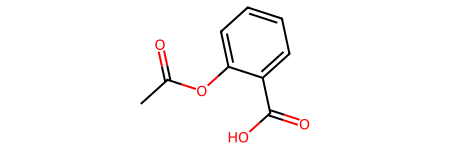

In [5]:
aspirin = Chem.MolFromSmiles('O=C(C)Oc1ccccc1C(=O)O')
aspirin

In [6]:
#if we check the object type, we find it is a Molecule (rdchem.Mol) RDKit Object
type(aspirin)

rdkit.Chem.rdchem.Mol

## 15.2 Visualising Chemical Structures

In the above examples, RDKit provided an image of the molecule simply by Jupyter running the Molecule object. By default, this generates a rather small and low-resolution image. To generate a sharper image, like above, running the following code at the top of a notebook changes the settings to produce SVG (Scalable Vector Graphic) images, which are a vector graphic format.

In [7]:
from rdkit.Chem.Draw import IPythonConsole
IPythonConsole.ipython_useSVG = True

### 15.2.1 Single Chemical Structures
However, simply running the Molecule object does not provide easy control over the image. In this section, we will generate images that can be saved along with visualizing grids of molecules and other visual representations.

To view the molecule, we can use the `Chem.Draw.MolToImage(Mol)` function, which takes one required positional argument of the Molecule object (`Mol`). Optional keyword arguments can be used to set other parameters such as the image size (`size=`) in pixels.

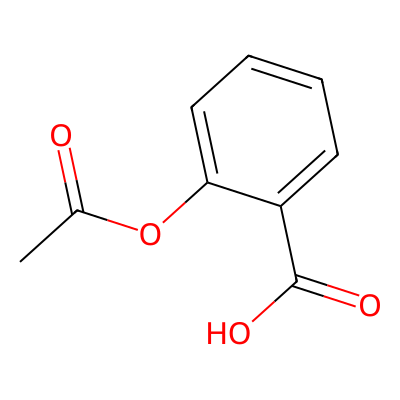

In [8]:
Chem.Draw.MolToImage(aspirin, size=(400,400))

If we want to save the image to a file, this is accomplished using the `Chem.Draw.MolToFile()` function, which requires two pieces of information - the Molecule object and the name of the new file as a string.

```python
Chem.Draw.MolToFile(mol_object, 'file_name.png', size=(width, height), imageType='png')
```

Other optional parameters include the size= which is a tuple that takes the width and height, respectively, in pixels, and the imageType= accepts a string to designate the file format (‘png’ or ‘svg’).

```python
Chem.Draw.MolToFile(aspirin, 'aspirin.svg',
                    size=(500,500),
                    imageType='svg')
```

In [9]:
df = pd.read_csv('data/amino_acid_SMILES.txt', skiprows=2)
df.head()

,name,SMILES
0,alanine,C[C@@H](C(=O)[O-])[NH3+]
1,arginine,[NH3+][C@@H](CCCNC(=[NH2+])N)C(=O)[O-]
2,asparagine,O=C(N)C[C@H]([NH3+])C(=O)[O-]
3,aspartate,C([C@@H](C(=O)[O-])[NH3+])C(=O)[O-]
4,cysteine,C([C@@H](C(=O)[O-])[NH3+])S


In [10]:
AminoAcids = [Chem.MolFromSmiles(SMILES) for SMILES in df['SMILES']]
AminoAcids

To generate the grid, we will use the `MolsToGridImage()` function from the `Chem.Draw` submodule. This function requires one positional argument of an array-like object (e.g., list, tuple, ndarray, etc.) containing the Molecule objects. 

Other optional keyword arguments include the number of molecules per row (`molsPerRow=`), the pixel dimensions of each molecule (`subImgSize=`), labels below each molecule (`legends=`), and the ability to make images in SVG format (`usesSVG=`). 

The image dimensions only matter if using a raster image format and require a tuple with the width and height in that order. The `legends=` argument requires an array-like object with the labels in the same order as the object containing the Molecule objects.

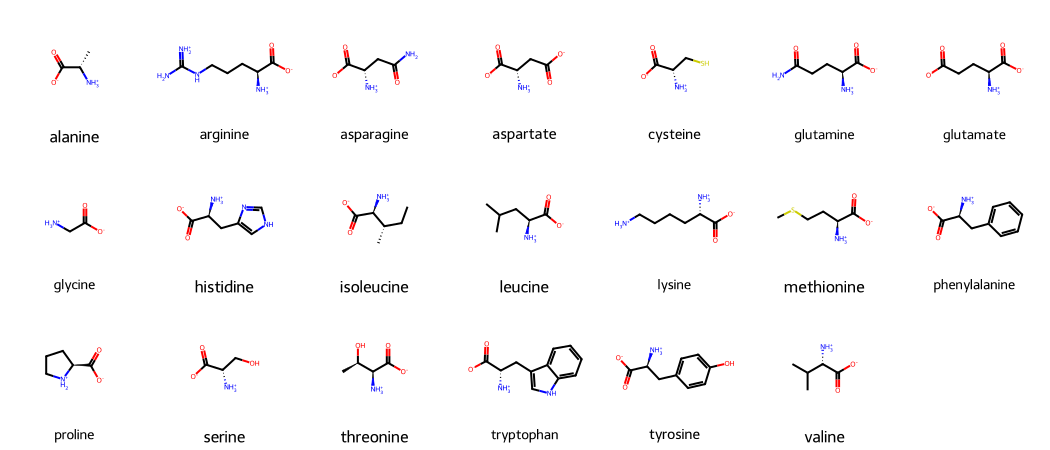

In [11]:
Chem.Draw.MolsToGridImage(AminoAcids, 
                          molsPerRow=7,
                          subImgSize=(150,150),
                          legends=list(df['name']),
                          useSVG=True)    

### Molecules in Pandas DataFrame

RDKit also supports visualizing molecules inside pandas DataFrames using the `AddMoleculeColumnToFrame()` function from the PandasTools submodule (`rdkit.Chem.PandasTools`). This function accepts a DataFrame with a column of SMILES (`smilesCol=`) and adds a new column of Molecule objects. The `molCol=` parameter will be the header for the new column.

In [12]:
ligands = pd.read_csv('data/ligands.csv')
ligands

,ligand,smiles
0,dppe,c1ccc(P(CCP(c2ccccc2)c2ccccc2)c2ccccc2)cc1
1,acac,CC(=O)CC(C)=O
2,acetonitrile,CC#N
3,dcpe,C1CCC(P(CCP(C2CCCCC2)C2CCCCC2)C2CCCCC2)CC1
4,HMDS,C[Si](C)(C)N[Si](C)(C)C
5,PPh3,c1ccc(P(c2ccccc2)c2ccccc2)cc1


,ligand,smiles,molecules
0,dppe,c1ccc(P(CCP(c2ccccc2)c2ccccc2)c2ccccc2)cc1,
1,acac,CC(=O)CC(C)=O,
2,acetonitrile,CC#N,
3,dcpe,C1CCC(P(CCP(C2CCCCC2)C2CCCCC2)C2CCCCC2)CC1,
4,HMDS,C[Si](C)(C)N[Si](C)(C)C,
5,PPh3,c1ccc(P(c2ccccc2)c2ccccc2)cc1,

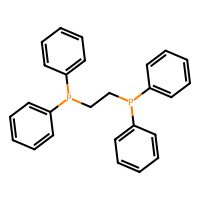
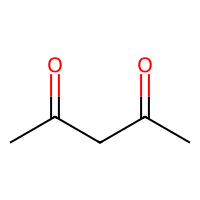
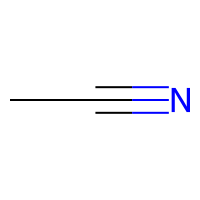
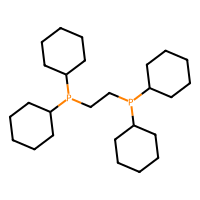
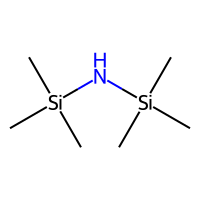
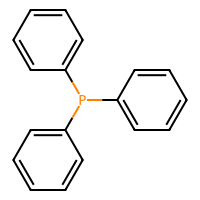

In [13]:
PandasTools.AddMoleculeColumnToFrame(ligands,
                                     smilesCol = 'smiles',
                                     molCol = 'molecules')
ligands

The DataFrame can also be exported as an Excel spreadsheet complete with images using the `SaveXlsxFromFrame()`. The function accepts the DataFrame name, output fle, name of Molecule object column and the image size as arguments.

```python
PandasTools.SaveXlsxFromFrame(ligands, 'ligands.xlsx', molCol= 'molecules', size=(300x300))
```

## 15.3 Stereochemistry

RDKit can assign the stereochemistry of stereocenters, including chiral centers (R vs. S) and alkene stereocenters (E vs. Z), determine the number of isomers possible, and even generate all possible isomers. 

Whether or not any stereochemistry is designated in the SMILES representation or Molecule object is an important detail in carrying out the above tasks. Even though a molecule may contain a chiral center or an alkene carbon, the stereochemistry around that atom may be ambiguous.

The SMILES representation shows stereochemistry around a tetrahedral carbon with either @ or @@ and around an alkene with \ and / symbols. If the SMILES representation does not include these symbols, the stereochemistry is not indicated.

Table 3 - SMILES Stereochemical Designations
|Designation|Alkene|Chiral SP3 Atom|
|-----------|------|---------------|
|No isomer designation|C(=CC)C|CCC(C)0|
First Isomer|C/C=C\C|CC\[C@H](C)O
Second Isomer|C/C=C/C|CC\[C@@H](C)O

### 15.3.1 Assigning Stereochemistry

The first task is to assign the absolute stereochemistry of a molecule. As an example, bellow we have a single isomer of pent-3-en-2-ol which has a single chiral center and an alkene could be either E or Z. RDKit can tell us the absolute configuration (R or S) of the terahedral chiral center and if the alkene is E or Z.

First we can load the SMILES representation (`O[C@@H](C)/C=C/C`) which contains both the @ and / symbols so we know the stereochemistry is assigned in this representation. When we visualise it we can see this reflected in the wedge bond for the methyl chiral center.

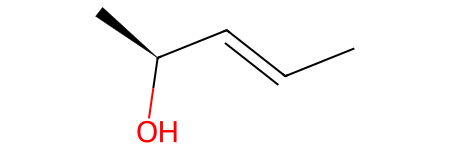

In [14]:
pentenol = Chem.MolFromSmiles('O[C@@H](C)/C=C/C')
pentenol

To obtain the absolute configuration we can use `Chem.FindMolChiralCenters()` which returns the absolute configuration and an index indicating which atom has that configuration 

In [15]:
Chem.FindMolChiralCenters(pentenol)

[(1, 'S')]

Our pent-3-en-2-ol isomer above has an S stereocenter. Being that pent-3-en-2-ol has only one chiral center, it is not difficult to determine which atom has the stereochemistry, but if there are multiple chiral centers, it can get confusing. To see the atom indices and stereochemistry labels on the molecule, this can be enabled (or disabled using `False`) by the following code.

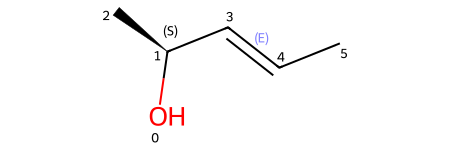

In [16]:
IPythonConsole.drawOptions.addAtomIndices = True
IPythonConsole.drawOptions.addStereoAnnotation = True

pentenol

To obtain the stereochemistry of double bonds, we can iterate through the bonds and obtain the stereochemistry using the `GetStereo()` bond method which has three possible outputs

Table 4 - Bond Stereochemistry Designations in RDKit
|Output|Description|
|------|-----------|
STEREONONE|No Stereochemistry (often not a pi bond)
STEREOE| E Stereochemistry
STEREOZ| Z Stereochemistry



In [17]:
for bond in pentenol.GetBonds():
    print (bond.GetStereo())

STEREONONE
STEREONONE
STEREONONE
STEREOE
STEREONONE


This will show in order 0-1,1-2... however in a bigger molecule this could be less easily interpreted. 

To make this clearer we can use the arguments `GetBeginAtom()`, `GetEndAtom()` and `GetSymbol()` to get the atom the bond starts and ends to along with the arguments `GetBeginAtomIdx()` and `GetEndAtomIdx()` which takes the atom indices we made `True` earlier to make this easy to visualise

In [18]:
for bond in pentenol.GetBonds():
    begin_atom = bond.GetBeginAtom().GetSymbol()
    end_atom = bond.GetEndAtom().GetSymbol()
    begin_idx = bond.GetBeginAtomIdx()
    end_idx = bond.GetEndAtomIdx()
    print(f'Bond {begin_atom}{begin_idx}-{end_atom}{end_idx}: {bond.GetStereo()}')

Bond O0-C1: STEREONONE
Bond C1-C2: STEREONONE
Bond C1-C3: STEREONONE
Bond C3-C4: STEREOE
Bond C4-C5: STEREONONE


In the above example, there are four bonds with no stereochemistry due to being single bonds, and there is one E bond corresponding to the alkene. If there are multiple double bonds, it can be difficult to determine which bond has which stereochemistry. In this case, either use the image like shown above or use additional bond methods (see section 15.6) to obtain more information about the bonds.

As another example, below we will look at the bonds in 9-cis-retinoic acid, where we can see examples of all three possible bond stereochemical assignments.

In [19]:
retinoic = Chem.MolFromSmiles(r'O=C(O)\C=C(\C=C\C=C(/C=C/C1=C(/CCCC1(C)C)C)C)C')

for bond in retinoic.GetBonds():
    begin_atom = bond.GetBeginAtom().GetSymbol()
    end_atom = bond.GetEndAtom().GetSymbol()
    begin_idx = bond.GetBeginAtomIdx()
    end_idx = bond.GetEndAtomIdx()
    print(f'Bond {begin_atom}{begin_idx}-{end_atom}{end_idx}: {bond.GetStereo()}')

Bond O0-C1: STEREONONE
Bond C1-O2: STEREONONE
Bond C1-C3: STEREONONE
Bond C3-C4: STEREOE
Bond C4-C5: STEREONONE
Bond C5-C6: STEREOE
Bond C6-C7: STEREONONE
Bond C7-C8: STEREOZ
Bond C8-C9: STEREONONE
Bond C9-C10: STEREOE
Bond C10-C11: STEREONONE
Bond C11-C12: STEREONONE
Bond C12-C13: STEREONONE
Bond C13-C14: STEREONONE
Bond C14-C15: STEREONONE
Bond C15-C16: STEREONONE
Bond C16-C17: STEREONONE
Bond C16-C18: STEREONONE
Bond C12-C19: STEREONONE
Bond C8-C20: STEREONONE
Bond C4-C21: STEREONONE
Bond C16-C11: STEREONONE


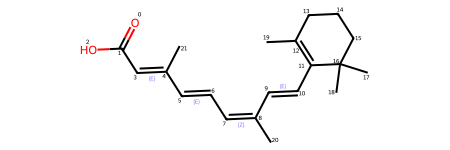

In [20]:
retinoic

### 15.3.2 Counting and Generating Isomers
Another interesting feature of RDKit is the ability to determine the number of stereoisomers possible for a given structure and to generate the different isomers. In both these applications, RDKit treats any explicitly assigned stereocenter as fixed and will not allow it to be changed. 

For example, below we will again look at (2S, 3E)-pent-3-en-2-ol. Because the structure already designates this as the (2S, 3E) isomer, the stereochemistry of the chiral center and alkene cannot be changed. As a result, when using the `GetStereoisomerCount()` method from the `EnumerateStereoisomers` module, it returns a `1`, indicating that there is only one stereoisomer possible with these constraints.



In [21]:
Chem.EnumerateStereoisomers.GetStereoisomerCount(pentenol)

1

In contrast if we provide the `GetStereoisomerCount()` function hexan-2-ol without any stereochemistry designated, it returns `2` as the number of stereoisomers. This is because bot (S)- and (R)- hexan-2ol are possible isomers

In [22]:
hexanol = Chem.MolFromSmiles('OC(C)CCCC')
Chem.EnumerateStereoisomers.GetStereoisomerCount(hexanol)

2

The `EnumerateStereoisomers` module can also generate the different possible isomers, and again it will only generate isomers by changing stereochemical features that do not already have assigned configurations. If we again look at hexan-2-ol, it generates two Molecule objects which are the two isomers.

In [23]:
isomers = list(Chem.EnumerateStereoisomers.EnumerateStereoisomers(hexanol))
isomers

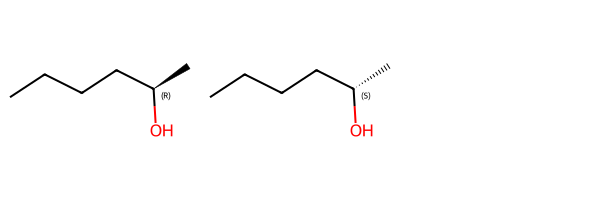

In [24]:
IPythonConsole.drawOptions.addAtomIndices = False
IPythonConsole.drawOptions.addStereoAnnotation = True

Chem.Draw.MolsToGridImage(isomers)

A more difficult example would be arabinose which has three chiral centers allowing for up to eight possible stereoisomers. Because there is asymmetry between top and bottom (i.e. -CHO and -CH2OH are different) no meso compound can exist, so it will have the full eight stereoisomers. We can get RDKit to draw out all eight for us.

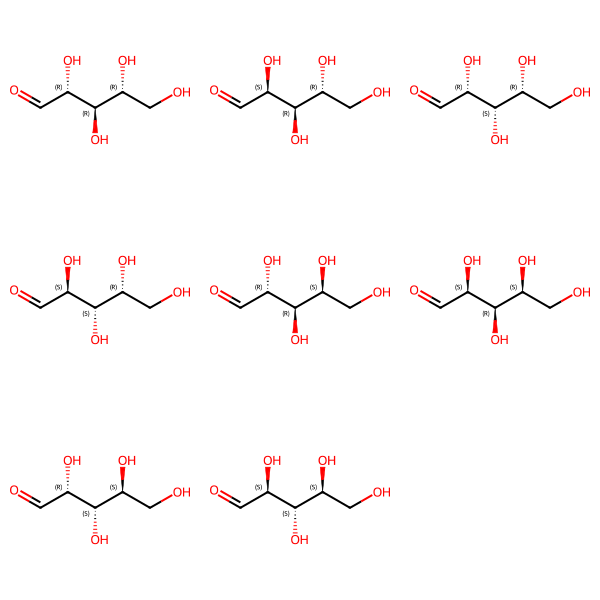

In [25]:
arabinose = Chem.MolFromSmiles('O=CC(O)C(O)C(O)CO')
isomers2 = list(Chem.EnumerateStereoisomers.EnumerateStereoisomers(arabinose))

Chem.Draw.MolsToGridImage(isomers2)

While the examples above mainly focus on stereoisomers from tetrahedral chiral centers, this also works with E/Z isomerisation. A limitation with RDKit is that it struggles to recognise E/Z isomers when there are stereocenters which do not have chiral centers involved such as rings.

For example 1,2,3-trimethylcyclopropane where it hallucinates that there are eight stereoisomers when in fact there are two.

## 15.4 `Chem.Descriptor` Module

RDKit can be used to determine a number of key physical properties of molecules known as descriptors using the `Chem.Descriptor` module. These can be useful for generating features for a larger number of molecules for machine learning or understanding structural trends in a body of chemical compounds.

### 15.4.1 Molecular Features
There are numerous descriptor features which are available, callable using `Chem.Descriptors.Method()` where`method()` is the name of a descriptor function that accepts an RDKit molecule object and returns a numerical value. Below are a few example of descriptor functions.

Table 5 - Examples of Molecular Descriptors
| Function | Description |
|---|---|
| `MolWt` | Molecular weight, assumes natural isotopic distribution |
| `HeavyAtomCount()` | Number of non-hydrogen atoms |
| `NOCount()` | Number of N and O atoms |
| `NumAliphaticRings()` | Number of aliphatic rings |
| `NumAromaticRings()` | Number of aromatic rings |
| `NumSaturatedRings()` | Number of saturated rings |
| `NumHAcceptors()` | Number of hydrogen bond acceptors |
| `NumHDonors()` | Number of hydrogen bond donors |
| `NumRadicalElectrons()` | Number of radical electrons |
| `NumValenceElectrons()` | Number of valence electrons |
| `NumRotatableBonds()` | Number of rotatable bonds |
| `RingCount()` | Number of rings |

We will look at some of these descriptor functions demonstrated on the compound paclitaxel. Specifically we will generate the molecular weight, number of rings, number of aromatic rings, number of valence electrons and number of rotatable bonds.

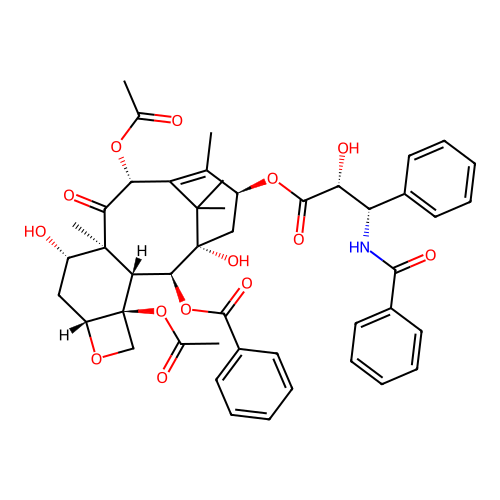

In [26]:
ptx = Chem.MolFromSmiles('CC1=C2[C@@]([C@]([C@H]([C@@H]3[C@]4([C@H](OC4)C[C@@H]'\
                         '([C@]3(C(=O)[C@@H]2OC(=O)C)C)O)OC(=O)C)OC(=O)c5ccccc5)'\
                         '(C[C@@H]1OC(=O)[C@H](O)[C@@H](NC(=O)c6ccccc6)c7ccccc7)O)(C)C')

AllChem.Compute2DCoords(ptx) # makes molecule display more clearly
Chem.Draw.MolToImage(ptx, size=(500,500))

In [27]:
# molecular weight
Chem.Descriptors.MolWt(ptx)

853.9180000000003

In [28]:
# number of rings
Chem.Descriptors.RingCount(ptx)

7

In [29]:
# number of aromatic rings
Chem.Descriptors.NumAromaticRings(ptx)

3

In [30]:
# number of valence electrons
Chem.Descriptors.NumValenceElectrons(ptx)

328

In [31]:
# number of rotable bonds
Chem.Descriptors.NumRotatableBonds(ptx)

10

### 15.4.2 Quantifying Functional Groups

Among the descriptor methods is a long list of functions that follow the format `fr_group()` where `group` is the name or abbreviation of a functional group. These functions return an integer quantification of that functional group present in the molecule


| Function | Functional Group |
|---|---|
| `fr_Al_OH()` | Aliphatic alcohols |
| `fr_aldehyde()` | Aldehydes |
| `fr_amide()` | Amide |
| `fr_C_O()` | Carbonyl oxygens |
| `fr_guanido()` | Guanidine |
| `fr_NH0()` | Amines with 0 H's (i.e., tertiary) |
| `fr_phenol()` | Phenol |
| `fr_phos_ester()` | Phosphoric ester |
| `fr_SH()` | Thiol |

In [32]:
# number of benzene rings
Chem.Descriptors.fr_benzene(ptx) 

3

In [33]:
# number of aliphatic alcohols
Chem.Descriptors.fr_Al_OH(ptx)

3

In [34]:
# number of aromatic carboxyls
Chem.Descriptors.fr_Ar_COO(ptx)

0

In [35]:
# number of esters
Chem.Descriptors.fr_ester(ptx)

4

## 15.5 Searching Molecules for Structural Patterns

Molecules can be searched for key structural features using the `HasSubstructMatch()` method which returns `True` or `False` depending on if a structural pattern exists in a molecule or not. This function requires two RDKit Molecule objects - one Molecule object (`molecule`) is checked for the presence of the other Molecule object structure (`substructure`) as shown below. There are optional keyword parameters such as `useChirality=` which allows for chirality to be factored into whether there is a match or not. The default setting is `useChirality=False`.

```python
molecule.HasSubstructMatch(substructure, useChirality=False)
```

As an example, we will look for the presence of a carbonyl (i.e., C=O bond) in acetone and pent-3-en-2-ol below, so the substructure that we will search for is a `C=O`.

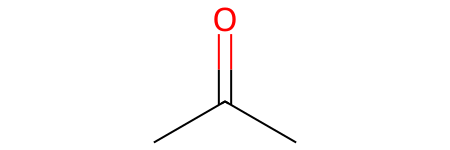

In [38]:
acetone = Chem.MolFromSmiles('CC(=O)C')
acetone

In [40]:
substructure = Chem.MolFromSmiles('C=O')  #Defines substructure as carboynl group
acetone.HasSubstructMatch(substructure)   #Returns True, as carbonyl is present in acetone

True

In [41]:
pentenol.HasSubstructMatch(substructure)

False

Not very surprisingly, the `HasSubstructMatch()` function returns `True` for acetone and `False` for the alcohol because the latter has a single CO bond, not a double. If we change our substructure to CO, we are now searching for a carbon-oxygen single bond (see Table 7), so acetone returns False while pent-3-en-2-ol returns True.

Table 7 - SMILES Bond order notation
|SMILES Bond|Bond Type|
|-----------|---------|
|- (or nothing)|Single |
|=|Double|
|#|Triple|
|:|Aromatic|

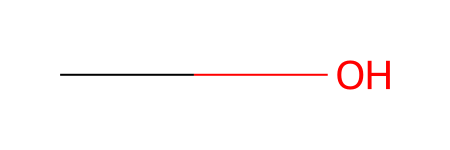

In [45]:
substructure = Chem.MolFromSmiles('CO')
substructure

In [46]:
acetone.HasSubstructMatch(substructure)

False

In [47]:
pentenol.HasSubstructMatch(substructure)

True

For a more interesting set of examples, we can search our collection of 20 common amino acids for key substructures. 

We will start by using **glycine**, the simplest of the common amino acids, as the substructure which should return all 20 amino acids. As an extra step below, we will also orient all the amino acids in the same way with respect to the substructure. That is, the substructural element that we are searching for in each amino acid will be oriented the same way for all 20 amino acids.

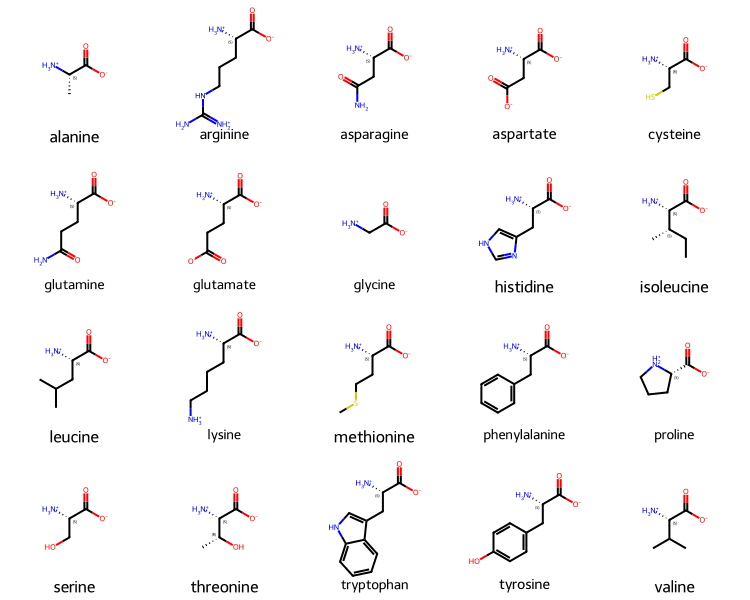

In [61]:
# searches for substructure
substructure= Chem.MolFromSmiles('C(C(=O)[O-])[NH3+]')
matching_amino_acids = [AA for AA in AminoAcids if AA.HasSubstructMatch(substructure)]

# orients common substructures the same way
AllChem.Compute2DCoords(substructure)
for amino_acid in matching_amino_acids:
    _ = AllChem.GenerateDepictionMatching2DStructure(amino_acid, substructure)

# generates grid of matching molecules
Chem.Draw.MolsToGridImage(matching_amino_acids, 
                          molsPerRow=5,
                          subImgSize=(150,150),
                          legends=list(df['name'])) 

Indeed, it did return all 20 amino acids, and notice how the core structures of all amino acids are oriented in the same direction. Now let us try something a little more interesting by searching for all amino acids with a benzene ring in them. The substructural bonding pattern in this case is benzene itself, and the three aromatic amino acids are returned.

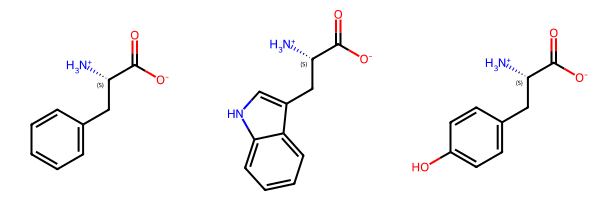

In [62]:
substructure = Chem.MolFromSmiles('c1ccccc1')
AA_with_pattern = [AA for AA in AminoAcids if AA.HasSubstructMatch(substructure)]

Chem.Draw.MolsToGridImage(AA_with_pattern)

It might be nice to still have the name labels for our three matches, so the above search is repeated but instead on a `zip` object comprised of the names of the amino acids and the Molecule objects.

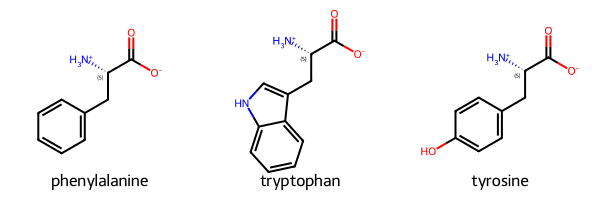

In [63]:
AA_zipped = list(zip(df['name'], AminoAcids))

substructure = Chem.MolFromSmiles('c1ccccc1')
with_pattern = [AA for AA in AA_zipped if AA[1].HasSubstructMatch(substructure)]

name = [AA[0] for AA in with_pattern]
mol_obj =  [AA[1] for AA in with_pattern]

Chem.Draw.MolsToGridImage(mol_obj, legends=name)

## 15.6 Atoms and Bonds

RDKit allows access to information on specific atoms and bonds through the `GetAtoms()` and `GetBonds()` methods, respectively. These functions return a sequence type of object that can be iterated through using a for loop to access individual atoms or bonds. Using the following methods, the user can access or even modify various pieces of information about the atoms or bonds. 
Below Table 9 and Table 10 contain some key functions for working with atoms and bonds.

Table 9 - Select Atom Methods

| Function | Description |
|---|---|
| `GetDegree()` | Returns number of atoms bonded directly to it, includes hydrogens only if they are explicitly defined |
| `GetAtomicNum()` | Returns atomic number |
| `GetChiralTag()` | Determines if the atom is a chiral center and CW or CCW designation |
| `GetFormalCharge()` | Returns formal charge of atom |
| `GetHybridization()` | Returns hybridization of atom |
| `GetIsAromatic()` | Returns bool as to whether atom is aromatic |
| `GetIsotope()` | Returns isotope number if designated, otherwise returns `0` |
| `GetNeighbors()` | Returns tuple of directly bonded atoms |
| `GetSymbol()` | Returns atomic symbols as a string |
| `GetTotalNumHs()` | Returns number of hydrogens bonded to the atom |
| `IsInRing()` | Returns bool designating if the atom is in a ring |
| `SetAtomicNum()` | Sets the atomic number to user defined value |
| `SetFormalCharge()` | Sets formal charge to user defined value |
| `SetIsotope()` | Sets isotope to user defined integer value |

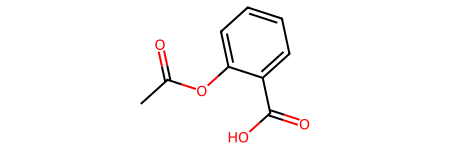

In [66]:
aspirin

If we generate a list populated with the degrees of atoms (i.e., number of other atoms bonded directly to it), you may notice that there are no 4 values even though the methyl (i.e., -CH3) carbon should have four atoms attached to it. This is because the hydrogen atoms are not explicitly designated in the structure (i.e., they are implicit), so they are not counted.

In [67]:
[atom.GetDegree() for atom in aspirin.GetAtoms()]

[1, 3, 1, 2, 3, 2, 2, 2, 2, 3, 3, 1, 1]

We can count the number of implicit hydrogens using the `GetNumImplicitHs()` method, and the third value is a `3` making it the methyl carbon.

In [68]:
[atom.GetNumImplicitHs() for atom in aspirin.GetAtoms()]

[0, 0, 3, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1]

We can also use these atom methods to change values and attributes of various atoms. For example, we can set the isotopes of the carbonyl carbons (i.e., C=O) to 13C. This is accomplished with the following code that iterates through all the atoms and finds the carbonyl carbons by testing for atoms that have an atomic number of 6, are not aromatic, and have no hydrogens, and then setting the isotope value to 13. The molecular weight is calculated before and after the isotopes are changed for comparison.

In [69]:
Chem.Descriptors.MolWt(aspirin)

180.15899999999996

In [70]:
for atom in aspirin.GetAtoms():
    if atom.GetAtomicNum() == 6 and \
        not atom.GetIsAromatic() and \
        atom.GetTotalNumHs() == 0:
    
        atom.SetIsotope(13)

182.14370968


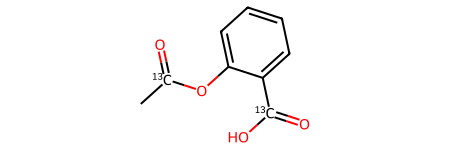

In [71]:
print(Chem.Descriptors.MolWt(aspirin))
aspirin

The molar mass has increased due to two of the carbon atoms being isotopically labeled, and we can see in the image which of the two carbons were isotopically labeled. It is worth noting that the molecular weight before isotopically labeling assumes a natural distribution of isotopes, which for carbon is 98.9% 12C and 1.1% 13C. In the isotopically labeled structure, the two carbonyl carbons are 100% 13C.

Using bond methods, we can perform analogous types of operations except that bonds have different attributes than atoms. A table of selected bond methods is provided below.

Table 10 - Select Bond Methods

| Function | Description |
|---|---|
| `GetBeginAtom()` | Returns first atom in bond |
| `GetEndAtom()` | Returns second atom in bond |
| `GetBondType()` | Returns type of bond (e.g., SINGLE, DOUBLE, AROMATIC) |
| `GetIsAromatic()` | Returns bool as to whether bond is aromatic |
| `GetIsConjugated()` | Returns bool as to whether bond is conjugated |
| `IsInRing()` | Returns bool as to whether bond is in ring |
| `SetBondType()` | Sets bond type |
| `SetIsAromatic()` | Sets bool designating if a bond is aromatic |

As a demonstration, we will examine the bonds in the structure of acetone and change the carbonyl double bond to a single bond. This is done by searching for a double bond, setting it to a single bond, and then changing the formal charges of the atoms attached to that bond.

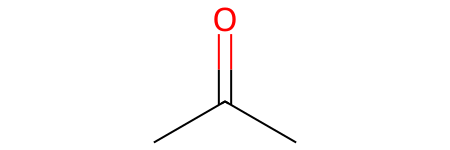

In [64]:
acetone

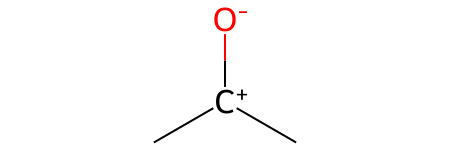

In [65]:
for bond in acetone.GetBonds():
    if bond.GetBondType() == Chem.BondType.DOUBLE:
        bond.SetBondType(Chem.BondType.SINGLE)
        bond.GetEndAtom().SetFormalCharge(-1)
        bond.GetBeginAtom().SetFormalCharge(+1)
acetone